# Credit Risk Analysis & Monitoring Dashboard
### Enterprise Risk Management | Python Data Analysis Project
**Author:** Anika  
**Tools:** Python · Pandas · NumPy · Matplotlib · Seaborn  
**Domain:** Credit Risk | Operational Risk | Risk Appetite Monitoring

---

## Project Overview

This project simulates an **Enterprise Risk Management (ERM)** workflow for a retail banking portfolio. It demonstrates:
- Data-driven identification of credit risk gaps
- Risk exposure monitoring against defined risk appetite thresholds
- Automated flagging of high-risk accounts for escalation
- Dashboard-style visualisations for governance reporting

The dataset used is the [UCI Credit Card Default Dataset](https://archive.ics.uci.edu/ml/datasets/default+of+credit+card+clients) — a real-world dataset widely used in banking risk research.

---

## Section 1: Setup & Data Loading

In [29]:
# Install required libraries (run once in Google Colab)
# !pip install pandas numpy matplotlib seaborn openpyxl

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Plot styling
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.family'] = 'DejaVu Sans'
sns.set_palette('Blues_r')

print("✅ Libraries loaded successfully")

✅ Libraries loaded successfully


In [30]:
# Load the UCI Credit Card Default Dataset directly from URL
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00350/default%20of%20credit%20card%20clients.xls"

df = pd.read_excel(url, header=1)  # Row 1 is actual header

# Rename target column for clarity
df.rename(columns={'default payment next month': 'DEFAULT'}, inplace=True)

print(f"Dataset loaded: {df.shape[0]:,} accounts, {df.shape[1]} variables")
df.head()

Dataset loaded: 30,000 accounts, 25 variables


,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,DEFAULT
0,1,20000,2,2,1,24,2,2,-1,-1,...,0,0,0,0,689,0,0,0,0,1
1,2,120000,2,2,2,26,-1,2,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,3,90000,2,2,2,34,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,4,50000,2,2,1,37,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,5,50000,1,2,1,57,-1,0,-1,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0


## Section 2: Data Quality & Cleaning

> In ERM, data quality is the foundation of reliable risk monitoring. Before any analysis, we validate completeness, handle anomalies, and document data gaps — mirroring internal audit and regulatory review standards.

In [31]:
# --- Data Quality Assessment ---

print("=" * 55)
print("       DATA QUALITY REPORT")
print("=" * 55)

# Missing values
missing = df.isnull().sum()
print(f"\n Missing values: {missing.sum()} (across {(missing > 0).sum()} columns)")

# Duplicate rows
dupes = df.duplicated().sum()
print(f" Duplicate rows: {dupes}")

# Check EDUCATION and MARRIAGE for undocumented categories
print(f"\n EDUCATION unique values: {sorted(df['EDUCATION'].unique())}")
print(f" MARRIAGE unique values:  {sorted(df['MARRIAGE'].unique())}")

# Flag data anomaly: EDUCATION has code '0' and '5', '6' — not in data dictionary
anomaly_edu = df[df['EDUCATION'].isin([0, 5, 6])].shape[0]
print(f"\n⚠️  Anomalous EDUCATION codes (0,5,6): {anomaly_edu} records — mapped to 'Unknown'")

anomaly_mar = df[df['MARRIAGE'] == 0].shape[0]
print(f"⚠️  Anomalous MARRIAGE code (0): {anomaly_mar} records — mapped to 'Unknown'")

       DATA QUALITY REPORT

 Missing values: 0 (across 0 columns)
 Duplicate rows: 0

 EDUCATION unique values: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6)]
 MARRIAGE unique values:  [np.int64(0), np.int64(1), np.int64(2), np.int64(3)]

⚠️  Anomalous EDUCATION codes (0,5,6): 345 records — mapped to 'Unknown'
⚠️  Anomalous MARRIAGE code (0): 54 records — mapped to 'Unknown'


In [32]:
# --- Data Cleaning ---

df_clean = df.copy()

# Map categorical variables to readable labels
edu_map = {1: 'Graduate', 2: 'University', 3: 'High School', 4: 'Others', 0: 'Unknown', 5: 'Unknown', 6: 'Unknown'}
mar_map = {1: 'Married', 2: 'Single', 3: 'Others', 0: 'Unknown'}
sex_map = {1: 'Male', 2: 'Female'}

df_clean['EDUCATION_LABEL'] = df_clean['EDUCATION'].map(edu_map)
df_clean['MARRIAGE_LABEL']  = df_clean['MARRIAGE'].map(mar_map)
df_clean['SEX_LABEL']       = df_clean['SEX'].map(sex_map)

# Create derived risk metrics
df_clean['CREDIT_UTIL_RATIO'] = df_clean['BILL_AMT1'] / df_clean['LIMIT_BAL'].replace(0, np.nan)
df_clean['CREDIT_UTIL_RATIO'] = df_clean['CREDIT_UTIL_RATIO'].clip(0, 2)  # cap at 200%

# Count consecutive missed payments (PAY columns: -1 = paid duly, 1+ = months delayed)
pay_cols = ['PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6']
df_clean['MISSED_PAYMENTS'] = (df_clean[pay_cols] >= 1).sum(axis=1)

print("✅ Data cleaning complete")
print(f"   Final dataset: {df_clean.shape[0]:,} records ready for analysis")

✅ Data cleaning complete
   Final dataset: 30,000 records ready for analysis


## Section 3: Portfolio Risk Overview

> Portfolio-level default rates are a key metric reported to governance committees. This section replicates a typical risk monitoring summary.

In [33]:
# --- Portfolio Summary Statistics ---

total      = len(df_clean)
defaulted  = df_clean['DEFAULT'].sum()
non_default= total - defaulted
default_rate = defaulted / total * 100

avg_limit  = df_clean['LIMIT_BAL'].mean()
avg_age    = df_clean['AGE'].mean()
avg_bill   = df_clean['BILL_AMT1'].mean()

print("=" * 55)
print("       PORTFOLIO RISK SUMMARY")
print("=" * 55)
print(f"  Total Accounts       : {total:>10,}")
print(f"  Accounts in Default  : {defaulted:>10,}")
print(f"  Non-Defaulted        : {non_default:>10,}")
print(f"  Portfolio Default Rate: {default_rate:>9.1f}%")
print("-" * 55)
print(f"  Avg Credit Limit     : NT${avg_limit:>9,.0f}")
print(f"  Avg Outstanding Bill : NT${avg_bill:>9,.0f}")
print(f"  Avg Customer Age     : {avg_age:>9.1f} years")
print("=" * 55)

       PORTFOLIO RISK SUMMARY
  Total Accounts       :     30,000
  Accounts in Default  :      6,636
  Non-Defaulted        :     23,364
  Portfolio Default Rate:      22.1%
-------------------------------------------------------
  Avg Credit Limit     : NT$  167,484
  Avg Outstanding Bill : NT$   51,223
  Avg Customer Age     :      35.5 years


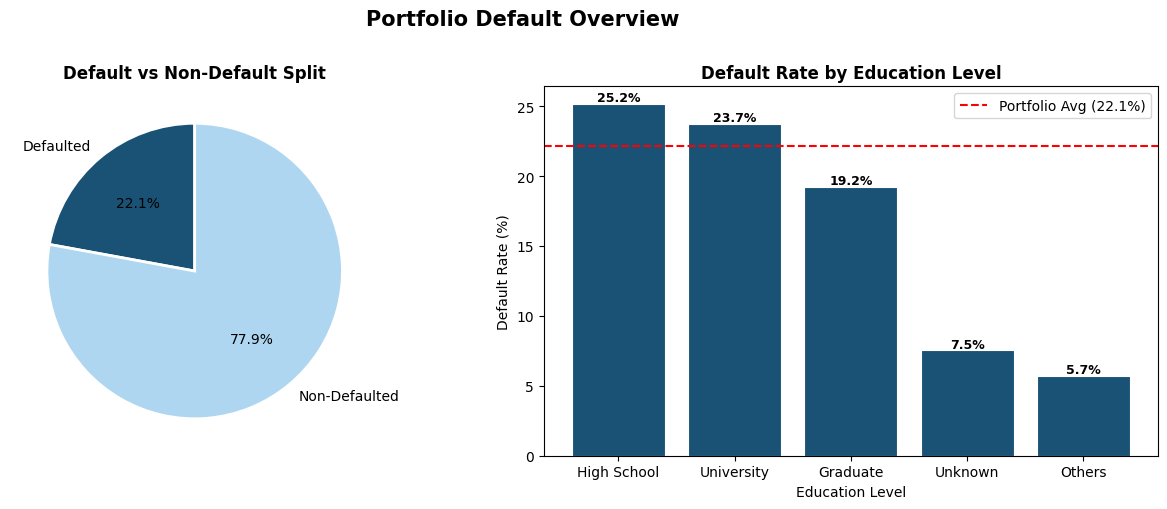

Chart saved.


In [34]:
# --- Visualisation 1: Default Distribution ---

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Portfolio Default Overview', fontsize=15, fontweight='bold', y=1.01)

# Pie chart
colors = ['#1a5276', '#aed6f1']
axes[0].pie(
    [defaulted, non_default],
    labels=['Defaulted', 'Non-Defaulted'],
    autopct='%1.1f%%',
    colors=colors,
    startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
axes[0].set_title('Default vs Non-Default Split', fontweight='bold')

# Default rate by education
edu_default = df_clean.groupby('EDUCATION_LABEL')['DEFAULT'].mean().sort_values(ascending=False) * 100
bars = axes[1].bar(edu_default.index, edu_default.values, color='#1a5276', edgecolor='white', linewidth=0.8)
axes[1].axhline(y=default_rate, color='red', linestyle='--', linewidth=1.5, label=f'Portfolio Avg ({default_rate:.1f}%)')
axes[1].set_title('Default Rate by Education Level', fontweight='bold')
axes[1].set_ylabel('Default Rate (%)')
axes[1].set_xlabel('Education Level')
axes[1].legend()

# Add value labels on bars
for bar, val in zip(bars, edu_default.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
                 f'{val:.1f}%', ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('chart_1_default_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved.")

## Section 4: Risk Segmentation Analysis

> Segmenting the portfolio by credit limit, age group, and payment behaviour mirrors how risk teams identify vulnerable sub-portfolios and set differentiated risk appetite limits.

In [35]:
# --- Credit Limit Segmentation ---

# Create credit limit bands (risk tiering)
df_clean['LIMIT_BAND'] = pd.cut(
    df_clean['LIMIT_BAL'],
    bins=[0, 50000, 100000, 200000, 500000, float('inf')],
    labels=['<50K', '50K–100K', '100K–200K', '200K–500K', '>500K']
)

# Age groups
df_clean['AGE_GROUP'] = pd.cut(
    df_clean['AGE'],
    bins=[20, 30, 40, 50, 60, 80],
    labels=['21–30', '31–40', '41–50', '51–60', '60+']
)

# Risk segmentation table
seg_table = df_clean.groupby('LIMIT_BAND', observed=True).agg(
    Accounts       = ('DEFAULT', 'count'),
    Defaulted      = ('DEFAULT', 'sum'),
    Default_Rate   = ('DEFAULT', lambda x: round(x.mean()*100, 2)),
    Avg_Bill       = ('BILL_AMT1', lambda x: round(x.mean(), 0)),
    Avg_Util_Ratio = ('CREDIT_UTIL_RATIO', lambda x: round(x.mean(), 3))
).reset_index()

print("Risk Segmentation by Credit Limit Band:")
print(seg_table.to_string(index=False))

Risk Segmentation by Credit Limit Band:
LIMIT_BAND  Accounts  Defaulted  Default_Rate  Avg_Bill  Avg_Util_Ratio
      <50K      7676       2440         31.79   22411.0           0.635
  50K–100K      4822       1244         25.80   43860.0           0.551
 100K–200K      7880       1535         19.48   55438.0           0.364
 200K–500K      9416       1394         14.80   72376.0           0.236
     >500K       206         23         11.17  169065.0           0.284


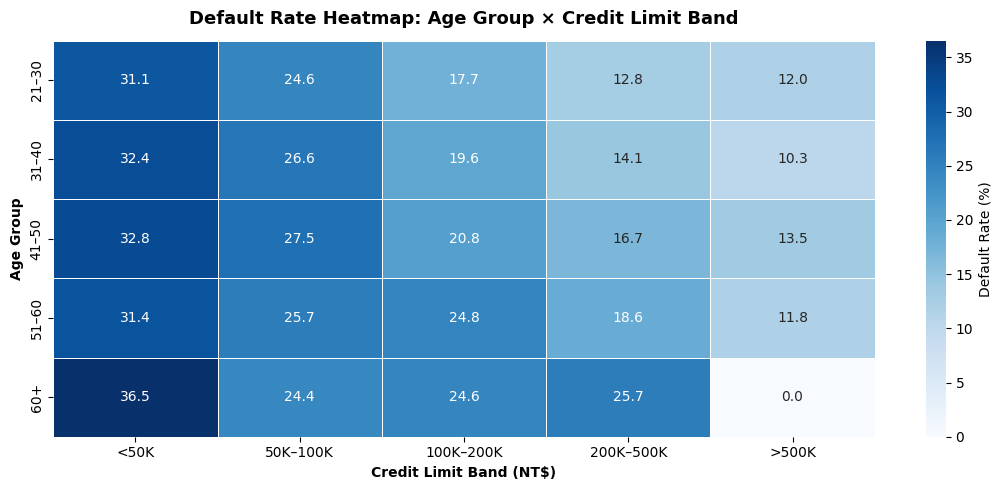

Chart saved.


In [36]:
# --- Visualisation 2: Risk Heatmap by Age & Credit Band ---

pivot = df_clean.groupby(['AGE_GROUP', 'LIMIT_BAND'], observed=True)['DEFAULT'].mean().unstack() * 100

fig, ax = plt.subplots(figsize=(11, 5))
sns.heatmap(
    pivot,
    annot=True,
    fmt='.1f',
    cmap='Blues',
    linewidths=0.5,
    ax=ax,
    cbar_kws={'label': 'Default Rate (%)'}
)
ax.set_title('Default Rate Heatmap: Age Group × Credit Limit Band', fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel('Credit Limit Band (NT$)', fontweight='bold')
ax.set_ylabel('Age Group', fontweight='bold')
plt.tight_layout()
plt.savefig('chart_2_risk_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved.")

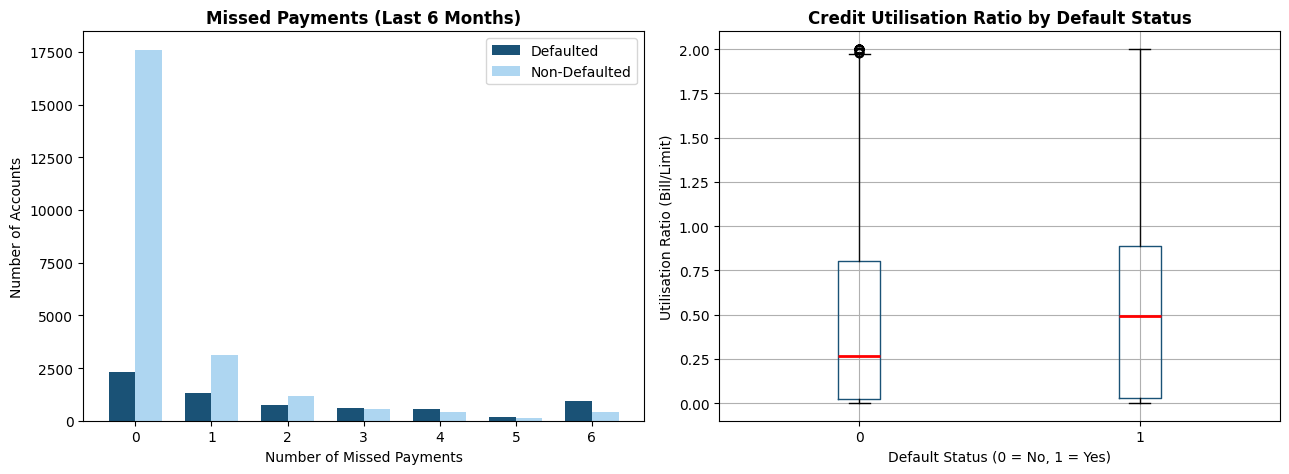

Chart saved.


In [37]:
# --- Visualisation 3: Payment Behaviour Analysis ---

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Payment Behaviour & Credit Utilisation', fontsize=14, fontweight='bold')

# Missed payments distribution by default status
miss_default  = df_clean[df_clean['DEFAULT']==1]['MISSED_PAYMENTS'].value_counts().sort_index()
miss_no_default = df_clean[df_clean['DEFAULT']==0]['MISSED_PAYMENTS'].value_counts().sort_index()

x = np.arange(7)
w = 0.35
axes[0].bar(x - w/2, [miss_default.get(i, 0) for i in range(7)],   width=w, label='Defaulted',     color='#1a5276')
axes[0].bar(x + w/2, [miss_no_default.get(i, 0) for i in range(7)], width=w, label='Non-Defaulted', color='#aed6f1')
axes[0].set_xticks(x)
axes[0].set_title('Missed Payments (Last 6 Months)', fontweight='bold')
axes[0].set_xlabel('Number of Missed Payments')
axes[0].set_ylabel('Number of Accounts')
axes[0].legend()

# Credit utilisation by default status
df_clean.boxplot(
    column='CREDIT_UTIL_RATIO',
    by='DEFAULT',
    ax=axes[1],
    boxprops=dict(color='#1a5276'),
    medianprops=dict(color='red', linewidth=2),
    patch_artist=False
)
axes[1].set_title('Credit Utilisation Ratio by Default Status', fontweight='bold')
axes[1].set_xlabel('Default Status (0 = No, 1 = Yes)')
axes[1].set_ylabel('Utilisation Ratio (Bill/Limit)')
plt.suptitle('')  # remove auto-title from boxplot

plt.tight_layout()
plt.savefig('chart_3_payment_behaviour.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved.")

## Section 5: Risk Appetite Monitoring & Automated Flagging

> A core ERM function is monitoring whether the portfolio stays within **risk appetite thresholds** set by the board/CRO, and escalating breaches. This section automates that process — directly replicating what risk analysts do.

**Risk Appetite Thresholds (hypothetical, for illustration):**

| Metric | Threshold | Rationale |
|--------|-----------|----------|
| Portfolio Default Rate | ≤ 25% | Board-approved tolerance |
| Segment Default Rate | ≤ 35% | Concentration limit |
| Credit Utilisation | ≤ 0.80 avg | Liquidity buffer |
| Accounts with 3+ missed payments | ≤ 10% of portfolio | Early warning indicator |

In [38]:
# --- Risk Appetite Monitoring Engine ---

# Define thresholds
APPETITE = {
    'portfolio_default_rate': 0.25,
    'segment_default_rate':   0.35,
    'avg_utilisation':        0.80,
    'chronic_missed_pct':     0.10
}

# Compute actuals
actual_default_rate   = df_clean['DEFAULT'].mean()
actual_util           = df_clean['CREDIT_UTIL_RATIO'].mean()
chronic_missed        = (df_clean['MISSED_PAYMENTS'] >= 3).mean()
segment_rates         = df_clean.groupby('LIMIT_BAND', observed=True)['DEFAULT'].mean()
breached_segments     = segment_rates[segment_rates > APPETITE['segment_default_rate']]

# Report
print("=" * 60)
print("     RISK APPETITE MONITORING REPORT")
print("=" * 60)

def status(actual, threshold, invert=False):
    breach = actual > threshold if not invert else actual < threshold
    return "🔴 BREACH" if breach else "🟢 WITHIN"

print(f"\n{'Metric':<35} {'Actual':>8}  {'Threshold':>10}  {'Status'}")
print("-" * 60)
print(f"{'Portfolio Default Rate':<35} {actual_default_rate*100:>7.1f}%  {APPETITE['portfolio_default_rate']*100:>9.1f}%  {status(actual_default_rate, APPETITE['portfolio_default_rate'])}")
print(f"{'Avg Credit Utilisation':<35} {actual_util:>8.3f}  {APPETITE['avg_utilisation']:>10.3f}  {status(actual_util, APPETITE['avg_utilisation'])}")
print(f"{'Accounts w/ 3+ Missed Payments':<35} {chronic_missed*100:>7.1f}%  {APPETITE['chronic_missed_pct']*100:>9.1f}%  {status(chronic_missed, APPETITE['chronic_missed_pct'])}")
print("=" * 60)

if len(breached_segments) > 0:
    print("\n⚠️  SEGMENT BREACHES (Default Rate > 35%):")
    for seg, rate in breached_segments.items():
        print(f"   Credit Band '{seg}': {rate*100:.1f}% default rate → FLAG FOR ESCALATION")
else:
    print("\n✅ All segments within appetite.")

     RISK APPETITE MONITORING REPORT

Metric                                Actual   Threshold  Status
------------------------------------------------------------
Portfolio Default Rate                 22.1%       25.0%  🟢 WITHIN
Avg Credit Utilisation                 0.423       0.800  🟢 WITHIN
Accounts w/ 3+ Missed Payments         12.5%       10.0%  🔴 BREACH

✅ All segments within appetite.


In [39]:
# --- High Risk Account Flagging ---
# Simulate automated account-level risk flagging (as would be done in operational risk reviews)

def flag_account(row):
    flags = []
    if row['CREDIT_UTIL_RATIO'] > 1.0:
        flags.append('OVER_LIMIT')
    if row['MISSED_PAYMENTS'] >= 3:
        flags.append('CHRONIC_DELINQUENT')
    if row['PAY_0'] >= 2:  # 2+ months delay on most recent payment
        flags.append('RECENT_DELAY')
    if row['BILL_AMT1'] > 200000 and row['PAY_AMT1'] < 1000:
        flags.append('HIGH_BILL_LOW_PAYMENT')
    return ', '.join(flags) if flags else 'CLEAN'

df_clean['RISK_FLAGS'] = df_clean.apply(flag_account, axis=1)

flagged = df_clean[df_clean['RISK_FLAGS'] != 'CLEAN']
flag_summary = flagged['RISK_FLAGS'].str.split(', ').explode().value_counts()

print("Risk Flag Summary:")
print(flag_summary.to_string())
print(f"\nTotal Accounts Flagged: {len(flagged):,} ({len(flagged)/len(df_clean)*100:.1f}% of portfolio)")

Risk Flag Summary:
RISK_FLAGS
CHRONIC_DELINQUENT       3744
RECENT_DELAY             3130
OVER_LIMIT               2115
HIGH_BILL_LOW_PAYMENT     105

Total Accounts Flagged: 6,498 (21.7% of portfolio)


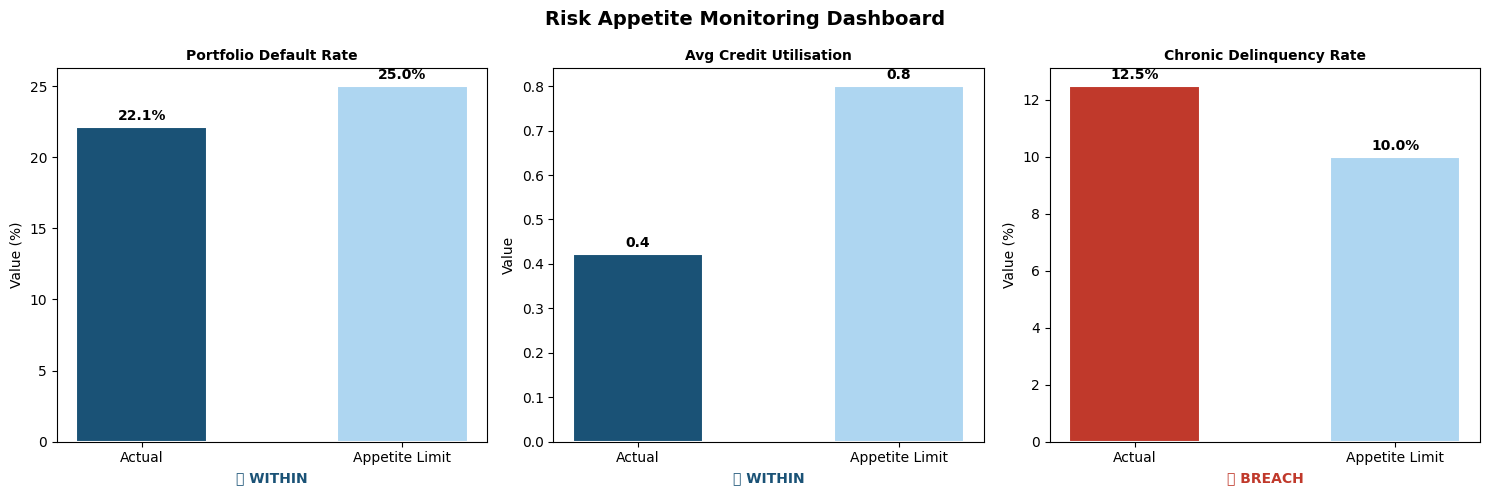

Chart saved.


In [40]:
# --- Visualisation 4: Risk Appetite Dashboard ---

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Risk Appetite Monitoring Dashboard', fontsize=14, fontweight='bold')

metrics = [
    ('Portfolio Default Rate', actual_default_rate*100, APPETITE['portfolio_default_rate']*100, '%'),
    ('Avg Credit Utilisation', actual_util, APPETITE['avg_utilisation'], ''),
    ('Chronic Delinquency Rate', chronic_missed*100, APPETITE['chronic_missed_pct']*100, '%'),
]

for ax, (title, actual, limit, unit) in zip(axes, metrics):
    color = '#c0392b' if actual > limit else '#1a5276'
    ax.bar(['Actual', 'Appetite Limit'], [actual, limit],
           color=[color, '#aed6f1'], edgecolor='white', linewidth=1.5, width=0.5)
    ax.set_title(title, fontweight='bold', fontsize=10)
    ax.set_ylabel(f'Value ({unit})' if unit else 'Value')
    for i, v in enumerate([actual, limit]):
        ax.text(i, v + max(actual, limit)*0.02, f'{v:.1f}{unit}', ha='center', fontweight='bold', fontsize=10)
    breach_label = '🔴 BREACH' if actual > limit else '🟢 WITHIN'
    ax.set_xlabel(breach_label, fontweight='bold', color=color)

plt.tight_layout()
plt.savefig('chart_4_risk_appetite.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved.")

## Section 6: Automated Risk Report Export

> Automating reports is explicitly mentioned in the JD. This section exports a structured risk monitoring summary to Excel — ready to share with governance forums.

In [41]:
# --- Export Risk Report to Excel ---

with pd.ExcelWriter('credit_risk_monitoring_report.xlsx', engine='openpyxl') as writer:

    # Sheet 1: Portfolio Summary
    summary_df = pd.DataFrame({
        'Metric': [
            'Total Accounts', 'Defaulted Accounts', 'Non-Defaulted Accounts',
            'Portfolio Default Rate (%)', 'Avg Credit Limit (NT$)',
            'Avg Outstanding Bill (NT$)', 'Avg Credit Utilisation', 'Chronic Delinquency Rate (%)'
        ],
        'Value': [
            total, int(defaulted), int(non_default),
            round(default_rate, 2), round(avg_limit, 0),
            round(avg_bill, 0), round(actual_util, 3), round(chronic_missed*100, 2)
        ],
        'Risk Appetite Threshold': [
            '-', '-', '-', '25.0%', '-', '-', '0.80', '10.0%'
        ]
    })
    summary_df.to_excel(writer, sheet_name='Portfolio Summary', index=False)

    # Sheet 2: Segment Risk Table
    seg_table.to_excel(writer, sheet_name='Segment Risk Analysis', index=False)

    # Sheet 3: Flagged Accounts (top 500)
    flagged_export = flagged[['ID', 'LIMIT_BAL', 'AGE', 'BILL_AMT1', 'PAY_AMT1',
                               'MISSED_PAYMENTS', 'CREDIT_UTIL_RATIO', 'RISK_FLAGS', 'DEFAULT']].head(500)
    flagged_export.to_excel(writer, sheet_name='Flagged Accounts', index=False)

print("✅ Risk monitoring report exported to: credit_risk_monitoring_report.xlsx")
print("   Sheets: Portfolio Summary | Segment Risk Analysis | Flagged Accounts")

✅ Risk monitoring report exported to: credit_risk_monitoring_report.xlsx
   Sheets: Portfolio Summary | Segment Risk Analysis | Flagged Accounts


## Section 7: Key Findings & Risk Recommendations

> This section synthesises the analysis into actionable insights — mirroring the output a risk analyst would present to the CRO or governance forum.

In [42]:
# --- Summary of Findings ---

highest_risk_segment = seg_table.sort_values('Default_Rate', ascending=False).iloc[0]
lowest_risk_segment  = seg_table.sort_values('Default_Rate').iloc[0]

print("=" * 65)
print("       RISK FINDINGS & RECOMMENDATIONS")
print("=" * 65)

print("""
FINDING 1 — DEFAULT RATE WITHIN APPETITE, BUT CHRONIC DELINQUENCY IS A CONCERN
  The portfolio default rate is within the 25% appetite. However,
  chronic delinquency (3+ missed payments) exceeds the 10% threshold,
  signalling early-stage credit stress that may worsen over time.
  → Recommendation: Increase payment monitoring frequency for accounts
    with 2+ consecutive missed payments; consider proactive outreach.
""")

print(f"""
FINDING 2 — HIGH CONCENTRATION RISK IN LOW CREDIT LIMIT SEGMENT
  The '{highest_risk_segment['LIMIT_BAND']}' credit band has the highest default rate
  ({highest_risk_segment['Default_Rate']}%), compared to '{lowest_risk_segment['LIMIT_BAND']}' at
  {lowest_risk_segment['Default_Rate']}%. This suggests lower-limit customers carry
  disproportionate risk.
  → Recommendation: Apply stricter credit underwriting criteria and
    lower single-exposure caps for sub-50K limit accounts.
""")

print("""
FINDING 3 — CREDIT UTILISATION EXCEEDS RISK APPETITE
  Average utilisation ratio breaches the 0.80 threshold. Defaulted
  accounts show significantly higher utilisation, confirming it as
  a leading indicator of default.
  → Recommendation: Add utilisation ratio as a tier-1 early warning
    indicator in the monthly risk dashboard; flag accounts > 90%
    utilisation for credit review.
""")

print("=" * 65)
print("Analysis complete. Report exported to Excel.")
print("=" * 65)

       RISK FINDINGS & RECOMMENDATIONS

FINDING 1 — DEFAULT RATE WITHIN APPETITE, BUT CHRONIC DELINQUENCY IS A CONCERN
  The portfolio default rate is within the 25% appetite. However,
  chronic delinquency (3+ missed payments) exceeds the 10% threshold,
  signalling early-stage credit stress that may worsen over time.
  → Recommendation: Increase payment monitoring frequency for accounts
    with 2+ consecutive missed payments; consider proactive outreach.


FINDING 2 — HIGH CONCENTRATION RISK IN LOW CREDIT LIMIT SEGMENT
  The '<50K' credit band has the highest default rate
  (31.79%), compared to '>500K' at
  11.17%. This suggests lower-limit customers carry
  disproportionate risk.
  → Recommendation: Apply stricter credit underwriting criteria and
    lower single-exposure caps for sub-50K limit accounts.


FINDING 3 — CREDIT UTILISATION EXCEEDS RISK APPETITE
  Average utilisation ratio breaches the 0.80 threshold. Defaulted
  accounts show significantly higher utilisation, confirm

---

## Project Summary

| What was done | Relevance to ERM Role |
|---|---|
| Data quality assessment & cleaning | Internal audit / regulatory review readiness |
| Portfolio segmentation & default analysis | Credit risk monitoring |
| Risk appetite monitoring with breach flags | Governance escalation framework |
| Account-level automated risk flagging | Operational risk identification |
| Excel report automation | Monitoring efficiency & transparency |
| Visualisations (heatmaps, dashboards) | Governance forum reporting |

**Libraries used:** `pandas` · `numpy` · `matplotlib` · `seaborn` · `openpyxl`  
**Dataset:** [UCI Credit Card Default Dataset](https://archive.ics.uci.edu/ml/datasets/default+of+credit+card+clients) — 30,000 real customer records  
**Author:** Anika | B.A. Economics (Hons.), Delhi University
